Dados carregados com sucesso!


<ipython-input-32-d807b8e182ed>:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features.fillna(method='ffill', inplace=True)
<ipython-input-32-d807b8e182ed>:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  targets.fillna(method='ffill', inplace=True)
<ipython-input-32-d807b8e182ed>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  targets.fillna(method='ffill', inplace=True)
<ipython-input-32-d807b8e182ed>:48: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  features[col] = features[col].view('int64')
/usr/local/lib/python3.11/dis

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step
Previsões para 2026 salvas com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

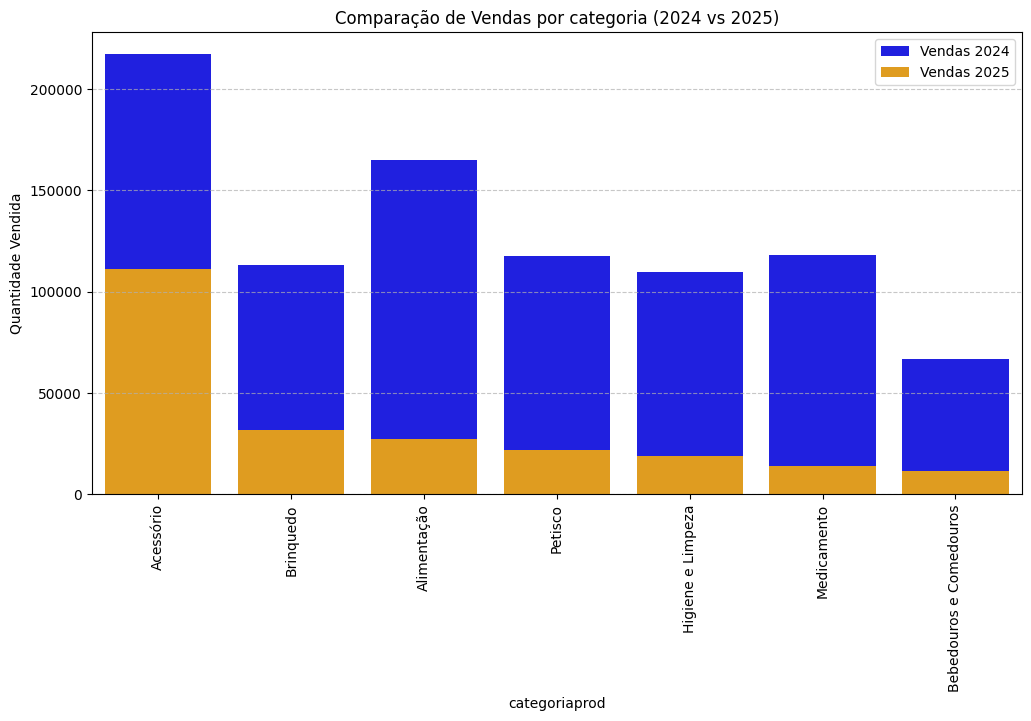

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import openpyxl
import os

label_encoders = {}

def carregar_dados(caminho_arquivo):
    try:
        dados = pd.read_excel(caminho_arquivo, engine='openpyxl', sheet_name='Planilha1')
        print("Dados carregados com sucesso!")
        return dados
    except Exception as e:
        print(f'Erro ao carregar os dados: {e}')
        raise

def tratar_colunas_categoricas(dados, colunas_categoricas):
    global label_encoders
    for coluna in colunas_categoricas:
        if coluna in dados.columns:
            le = LabelEncoder()
            dados[coluna] = le.fit_transform(dados[coluna])
            label_encoders[coluna] = le  # Salva o LabelEncoder
    return dados


def preparar_dados(dados, lookback, target_cols):
    scaler_features = MinMaxScaler()
    scaler_targets = MinMaxScaler()

    colunas_categoricas = ['produto',  'categoriaprod']

    dados = tratar_colunas_categoricas(dados, colunas_categoricas)

    features = dados.drop(columns=target_cols)
    targets = dados[target_cols]

    features.fillna(method='ffill', inplace=True)
    targets.fillna(method='ffill', inplace=True)

    for col in features.select_dtypes(include=['datetime64']).columns:
        features[col] = features[col].view('int64')

    features_normalizados = scaler_features.fit_transform(features)
    targets_normalizados = scaler_targets.fit_transform(targets)

    X, y = [], []
    for i in range(lookback, len(features_normalizados)):
        X.append(features_normalizados[i - lookback:i, :])
        y.append(targets_normalizados[i, :])

    return np.array(X), np.array(y), scaler_features, scaler_targets


def dividir_dados(X, y, train_size=0.8):
    split_idx = int(len(X) * train_size)
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

# Função para criar o modelo LSTM
def criar_modelo_lstm(input_shape, output_size):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=output_size)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


def treinar_modelo(model, X_train, y_train, epochs=50, batch_size=32):
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    return model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                     validation_split=0.1, verbose=0, callbacks=[early_stopping])


def fazer_previsao(model, X_test, scaler_targets):
    previsoes_normalizadas = model.predict(X_test)
    return scaler_targets.inverse_transform(previsoes_normalizadas)


caminho_arquivo = "/vendas_linha_petshop_2020_2024.xlsx"
lookback = 30
target_cols = ["quantidade", "categoriaprod"]

dados = carregar_dados(caminho_arquivo)
X, y, scaler_features, scaler_targets = preparar_dados(dados, lookback, target_cols)
X_train, X_test, y_train, y_test = dividir_dados(X, y)

modelo = criar_modelo_lstm((X_train.shape[1], X_train.shape[2]), y_train.shape[1])
historico = treinar_modelo(modelo, X_train, y_train, epochs=50, batch_size=32)

previsoes = fazer_previsao(modelo, X_test, scaler_targets)

df_previsoes_2026 = pd.DataFrame(previsoes, columns=target_cols)

# Reverter valores numéricos para as categorias
if "categoriaprod" in df_previsoes_2026.columns:
    le_categoria  = label_encoders.get("categoriaprod")
    if le_categoria:
        df_previsoes_2026["categoriaprod"] = le_categoria.inverse_transform(
            df_previsoes_2026["categoriaprod"].astype(int)
        )


if "categoriaprod" in dados.columns:
    le_categoria = label_encoders.get("categoriaprod")
    if le_categoria:
        dados["categoriaprod"] = le_categoria.inverse_transform(
            dados["categoriaprod"].astype(int)
        )


df_previsoes_2026.to_excel("previsoes_vendas_2026.xlsx", index=False)
print("Previsões para 2026 salvas com sucesso!")


from google.colab import files
files.download("previsoes_vendas_2026.xlsx")

# Comparação de vendas por categoria em 2024 vs 2026
df_vendas_2024 = dados.groupby("categoriaprod")["quantidade"].sum().reset_index()
df_vendas_2026 = df_previsoes_2026.groupby("categoriaprod")["quantidade"].sum().reset_index()

df_vendas_2024.rename(columns={"quantidade": "vendas_2024"}, inplace=True)
df_vendas_2026.rename(columns={"quantidade": "vendas_2026"}, inplace=True)

df_vendas_2024["categoriaprod"] = df_vendas_2024["categoriaprod"].astype(str)
df_vendas_2026["categoriaprod"] = df_vendas_2026["categoriaprod"].astype(str)

df_comparacao = pd.merge(df_vendas_2024, df_vendas_2026, on="categoriaprod", how="outer").fillna(0)

plt.figure(figsize=(12, 6))
df_comparacao = df_comparacao.sort_values(by="vendas_2026", ascending=False)  # Ordena para melhor visualização
ax = sns.barplot(x="categoriaprod", y="vendas_2024", data=df_comparacao, color="blue", label="Vendas 2024")
sns.barplot(x="categoriaprod", y="vendas_2026", data=df_comparacao, color="orange", label="Vendas 2025")

plt.xticks(rotation=90)
plt.xlabel("categoriaprod")
plt.ylabel("Quantidade Vendida")
plt.title("Comparação de Vendas por categoria (2024 vs 2025)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
